<a href="https://colab.research.google.com/github/dhruvi15/Machine-Learning-Lab-1/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ____________PART 1 — Data Preparation____________


# TODO 1: Load dataset
import pandas as pd
from sklearn.model_selection import train_test_split

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("assignment2_dataset.csv")

# First 5 rows

print(df.head())

# Separate features and target variables

# Feature columns used for prediction
features = [
    'Age',
    'WorkHours',
    'SleepHours',
    'AttendanceRate',
    'PreviousPerformance',
    'WellnessIndex'
]

X = df[features]

# Target 1: ProductivityScore (Regression)

y_reg = df['ProductivityScore']

# Target 2: PerformanceCategory (Classification)

def categorize_performance(score):
    if score > 85:
        return "High"
    elif score >= 70:
        return "Average"
    else:
        return "Low"

df['PerformanceCategory'] = df['ProductivityScore'].apply(categorize_performance)

y_cls = df['PerformanceCategory']

# Perform train-test split (80/20)

# Regression split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg,
    test_size=0.2,
    random_state=42
)

# Classification split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_cls,
    test_size=0.2,
    random_state=42
)

# Print shape of training and testing sets
print("Regression Training Shape:", X_train_reg.shape)
print("Regression Testing Shape:", X_test_reg.shape)

print("Classification Training Shape:", X_train_cls.shape)
print("Classification Testing Shape:", X_test_cls.shape)

Saving assignment2_dataset.csv to assignment2_dataset (2).csv
  EmployeeID  Gender  Age  WorkHours  SleepHours  AttendanceRate  \
0       E001    Male   29          8           7              92   
1       E002  Female   34          9           6              88   
2       E003    Male   41         10           5              95   
3       E004  Female   26          7           8              85   
4       E005    Male   38          9           6              90   

   PreviousPerformance EducationLevel RemoteWork  ProductivityScore  \
0                   78       Bachelor        Yes                 82   
1                   85         Master         No                 87   
2                   90            PhD         No                 92   
3                   72       Bachelor        Yes                 79   
4                   88         Master        Yes                 86   

   WellnessIndex AttendanceCategory  Gender_encoded  EducationLevel_encoded  \
0             56       

In [7]:
# ____________PART 2 — Supervised Learning: Regression____________


# TODO 2:
# 1. Import LinearRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 2. Train regression model
reg_model = LinearRegression()

# Fit model using training data
reg_model.fit(X_train_reg, y_train_reg)

# 3. Make predictions
y_pred_reg = reg_model.predict(X_test_reg)

# 4. Evaluate using:

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test_reg, y_pred_reg)

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test_reg, y_pred_reg)

# R2 Score
r2 = r2_score(y_test_reg, y_pred_reg)

print("Regression Model Evaluation")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)


Regression Model Evaluation
Mean Absolute Error (MAE): 1.201297206575326
Mean Squared Error (MSE): 1.9134624055893632
R2 Score: 0.9344424015215635


In [15]:
# ____________PART 3 — Supervised Learning: Classification____________

# TODO 3:
# 1. Create PerformanceCategory:
#    High Performer (>85)
#    Average (70–85)
#    Low (<70)
def create_category(score):
    if score > 85:
        return "High Performer"
    elif score >= 70:
        return "Average"
    else:
        return "Low"

# Apply function to create new column
df['PerformanceCategory'] = df['ProductivityScore'].apply(create_category)

# Check category distribution
print(df['PerformanceCategory'].value_counts())


# 2. Train a classifier (Logistic Regression or Decision Tree)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define features and target
X_cls = df[['Age','WorkHours','SleepHours','AttendanceRate','PreviousPerformance','WellnessIndex']]
y_cls = df['PerformanceCategory']

# Train-test split
from sklearn.model_selection import train_test_split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls,
    test_size=0.2,
    random_state=42
)

# Train classifier
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train_cls, y_train_cls)


# Make predictions
y_pred_cls = classifier.predict(X_test_cls)


# 3. Evaluate using:

# Accuracy
accuracy = accuracy_score(y_test_cls, y_pred_cls)

# Confusion Matrix
c_m = confusion_matrix(y_test_cls, y_pred_cls)

# Classification Report

C_report= classification_report(y_test_cls, y_pred_cls, zero_division=0)


# Print results
print("Classification Results")

print("Accuracy:", accuracy)

print("Confusion Matrix")
print(c_m)

print("Classification Report")
print(C_report)

PerformanceCategory
Average           10
High Performer    10
Name: count, dtype: int64
Category Distribution:
PerformanceCategory
Average           10
High Performer    10
Name: count, dtype: int64
Classification Results
Accuracy: 0.75
Confusion Matrix
[[3 0]
 [1 0]]
Classification Report
                precision    recall  f1-score   support

       Average       0.75      1.00      0.86         3
High Performer       0.00      0.00      0.00         1

      accuracy                           0.75         4
     macro avg       0.38      0.50      0.43         4
  weighted avg       0.56      0.75      0.64         4



Cluster Distribution
Cluster
2    9
0    6
1    5
Name: count, dtype: int64


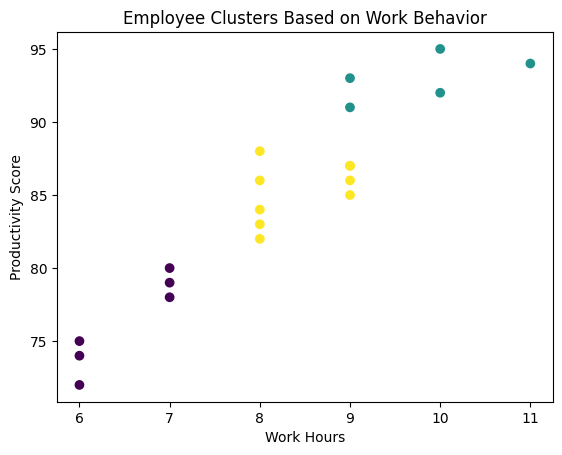

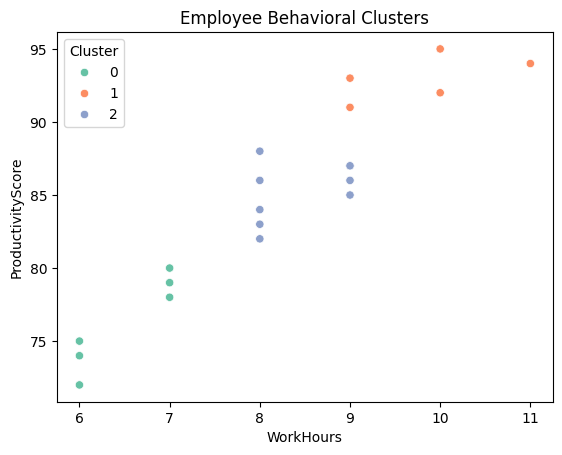

In [18]:
# ____________PART 4 — Unsupervised Learning: Clustering____________
import matplotlib.pyplot as plt

# TODO 4:
# 1. Select relevant features (e.g., WorkHours, SleepHours,
#    AttendanceRate, ProductivityScore)

cluster_features = df[['WorkHours', 'SleepHours', 'AttendanceRate', 'ProductivityScore']]

# 2. Apply K-Means with a fixed K (example: K = 3)

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

# 3. Apply KMeans clustering

clusters = kmeans.fit_predict(cluster_features)

# 4. Add cluster labels to dataframe

df['Cluster'] = clusters

print("Cluster Distribution")
print(df['Cluster'].value_counts())


# 5. Visualize clusters using scatter plot

plt.figure()

plt.scatter(
    df['WorkHours'],
    df['ProductivityScore'],
    c=df['Cluster']
)

plt.xlabel("Work Hours")
plt.ylabel("Productivity Score")
plt.title("Employee Clusters Based on Work Behavior")

plt.show()

# Visualize employee clusters using a scatter plot
# Seaborn is used here because it automatically adds a color legend
# The 'hue' parameter colors points based on cluster labels

import seaborn as sns

sns.scatterplot(
    x=df['WorkHours'],
    y=df['ProductivityScore'],
    hue=df['Cluster'],
    palette='Set2'
)

plt.title("Employee Behavioral Clusters")
plt.show()

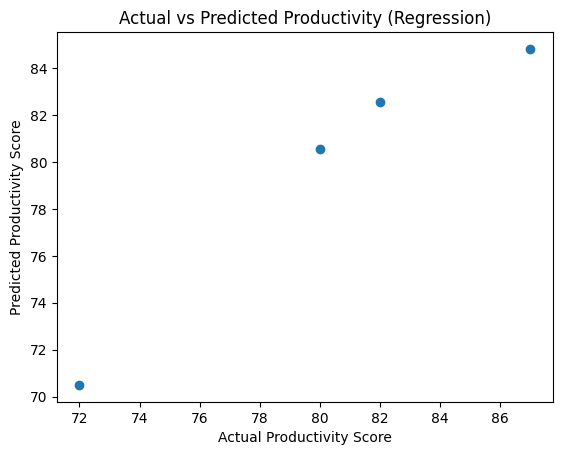

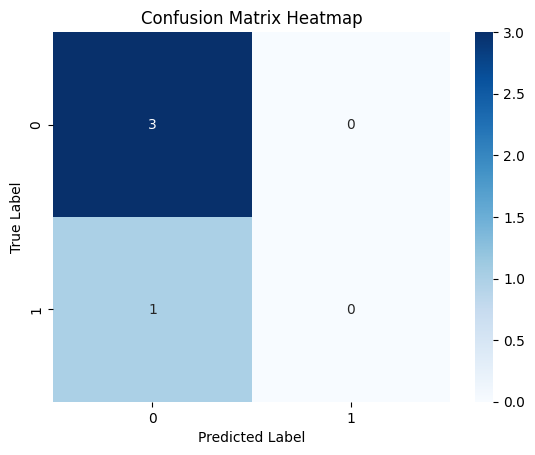

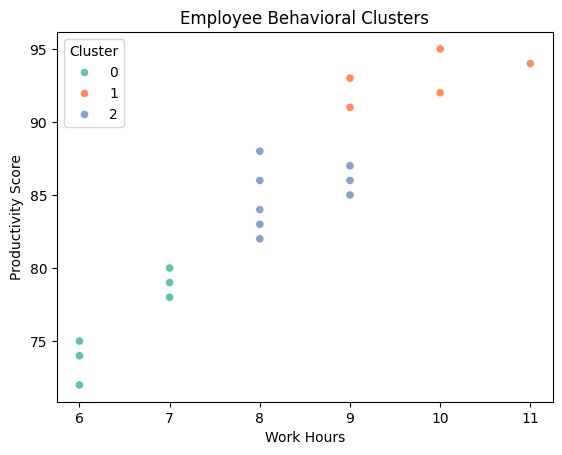

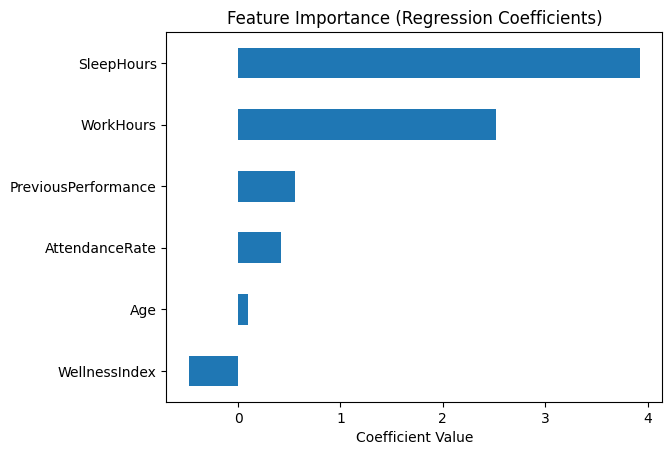

In [19]:
# ____________PART 5 — Visualization of Model Results____________

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# TODO 5:
# 1. Plot Actual vs Predicted (Regression)

plt.figure()

plt.scatter(y_test_reg, y_pred_reg)

plt.xlabel("Actual Productivity Score")
plt.ylabel("Predicted Productivity Score")

plt.title("Actual vs Predicted Productivity (Regression)")

plt.show()

# 2. Plot Confusion Matrix heatmap

plt.figure()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix Heatmap")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# 3. Plot Cluster visualization

plt.figure()

sns.scatterplot(
    x=df['WorkHours'],
    y=df['ProductivityScore'],
    hue=df['Cluster'],
    palette='Set2'
)

plt.title("Employee Behavioral Clusters")

plt.xlabel("Work Hours")
plt.ylabel("Productivity Score")

plt.show()

# 4. Plot Feature Importance
# Since we used Linear Regression, we can use model coefficients

import pandas as pd

importance = pd.Series(reg_model.coef_, index=X.columns)

plt.figure()

importance.sort_values().plot(kind='barh')

plt.title("Feature Importance (Regression Coefficients)")

plt.xlabel("Coefficient Value")

plt.show()

In this project, we analyzed employee productivity using different machine learning methods. Features such as work hours, attendance rate, and previous performance seemed to influence productivity the most.
The regression model helped predict the productivity score, while the classification model grouped employees into performance levels like high, average, and low performers.
 From the clustering results, I noticed that employees with similar work hours and productivity scores formed similar groups. This helped reveal patterns in employee behavior.
 Supervised learning was used when the model was trained with familiar outputs, while unsupervised learning was used to discover patterns in the data without predefined labels.